<a href="https://colab.research.google.com/github/antigravityjacky-bit/easyprediction/blob/main/Z_Image_Turbo_4bit_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U git+https://github.com/huggingface/diffusers git+https://github.com/Disty0/sdnq

  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-nw8riut4
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-nw8riut4
  Resolved https://github.com/huggingface/diffusers to commit 77f8cf8bf557a0136d269baea773cef26eb5991a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Disty0/sdnq to /tmp/pip-req-build-czq2arbz
  Running command git clone --filter=blob:none --quiet https://github.com/Disty0/sdnq /tmp/pip-req-build-czq2arbz
  Resolved https://github.com/Disty0/sdnq to commit bcf63fe8e6c669f01edbf6b97f6962c7f5c40a4f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 11.7 MB/s eta 0:00:00
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0

In [2]:
import torch
import diffusers
from sdnq import SDNQConfig # import sdnq to register it into diffusers and transformers
from sdnq.loader import apply_sdnq_options_to_model

pipe = diffusers.ZImagePipeline.from_pretrained("Disty0/Z-Image-Turbo-SDNQ-uint4-svd-r32", torch_dtype=torch.float32, device_map="cuda")
pipe.transformer = apply_sdnq_options_to_model(pipe.transformer, use_quantized_matmul=True)
pipe.text_encoder = apply_sdnq_options_to_model(pipe.text_encoder, use_quantized_matmul=True)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1406 [00:00<?, ?it/s]

In [18]:
import gc
import torch

# 刪除舊 pipeline
del pipe

# 清除 CUDA 快取
torch.cuda.empty_cache()
gc.collect()

print("GPU 記憶體已清除！")
print(f"剩餘 GPU 記憶體: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

GPU 記憶體已清除！
剩餘 GPU 記憶體: 6.95 GB


Saving 525501822_18523073599045370_3920397086677280403_n.jpg to 525501822_18523073599045370_3920397086677280403_n (6).jpg


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1406 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

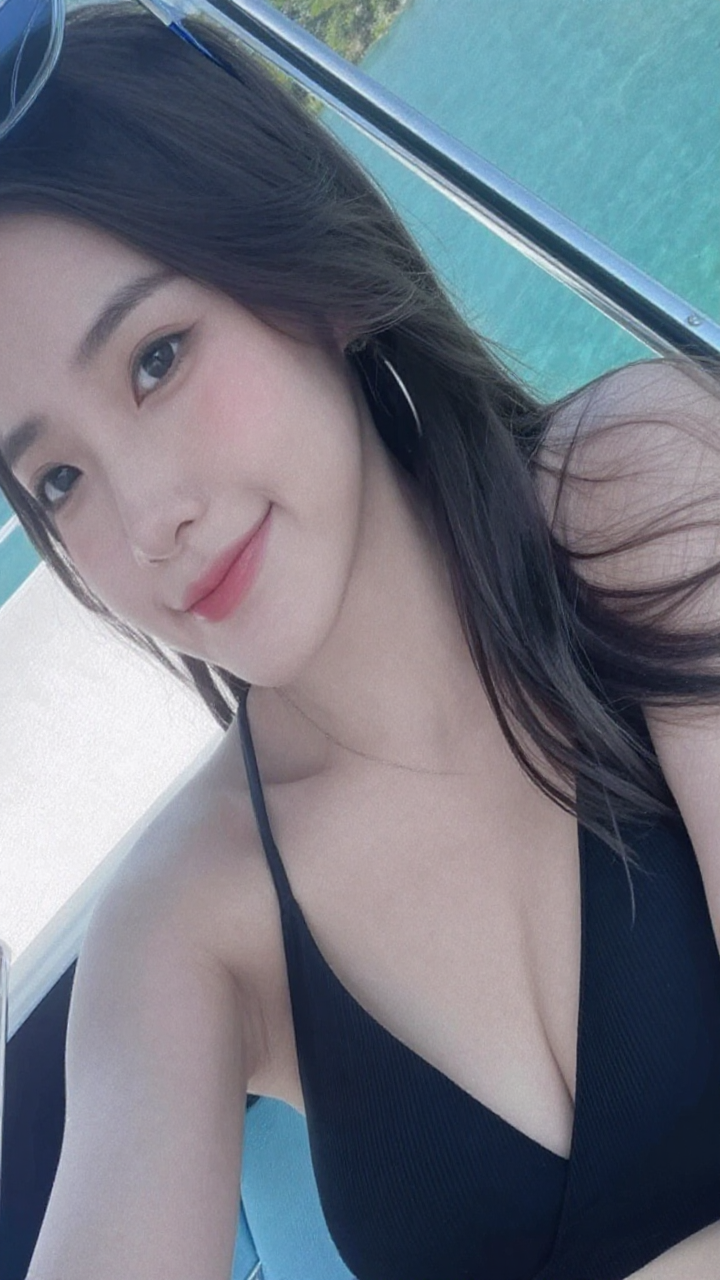

In [17]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"  # 解決碎片化問題

import torch
from diffusers import ZImageImg2ImgPipeline
from sdnq import SDNQConfig
from sdnq.loader import apply_sdnq_options_to_model
from PIL import Image
from google.colab import files

# ===== 上載圖片 =====
uploaded = files.upload()
filename = list(uploaded.keys())[0]
init_image = Image.open(filename).convert("RGB").resize((720, 1280))

# ===== 載入 Pipeline（加入記憶體優化）=====
pipe = ZImageImg2ImgPipeline.from_pretrained(
    "Disty0/Z-Image-Turbo-SDNQ-uint4-svd-r32",
    torch_dtype=torch.float32,
    device_map="cuda",
    low_cpu_mem_usage=True,   # ✅ 降低 CPU 記憶體使用
)

# ===== 應用量化（慳 GPU 記憶體）=====
pipe.transformer = apply_sdnq_options_to_model(pipe.transformer, use_quantized_matmul=True)
pipe.text_encoder = apply_sdnq_options_to_model(pipe.text_encoder, use_quantized_matmul=True)

# ===== 額外記憶體優化 =====
pipe.enable_attention_slicing()   # ✅ 分批處理 attention，大幅慳記憶體

# ===== Prompt =====
prompt = "把圖片中的人物改成smile in hotel room"

# ===== 生成圖片 =====
with torch.no_grad():  # ✅ 唔儲存 gradient，慳記憶體
    image = pipe(
        prompt,
        image=init_image,
        strength=0.3,
        num_inference_steps=9,
        guidance_scale=0.0,
        generator=torch.manual_seed(42),
    ).images[0]

display(image)
image.save("output_img2img.png")